In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn plotly joblib -q

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import joblib

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# Update this path if your file is in a different Drive location
df = pd.read_csv('/content/drive/MyDrive/fetal_health.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (2126, 22)

First 5 rows:


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [4]:
print("="*50)
print("DATASET BASIC INFO")
print("="*50)
print(f"Total Records  : {df.shape[0]}")
print(f"Total Features : {df.shape[1]}")
print(f"\nColumn Names:\n{list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

DATASET BASIC INFO
Total Records  : 2126
Total Features : 22

Column Names:
['baseline value', 'accelerations', 'fetal_movement', 'uterine_contractions', 'light_decelerations', 'severe_decelerations', 'prolongued_decelerations', 'abnormal_short_term_variability', 'mean_value_of_short_term_variability', 'percentage_of_time_with_abnormal_long_term_variability', 'mean_value_of_long_term_variability', 'histogram_width', 'histogram_min', 'histogram_max', 'histogram_number_of_peaks', 'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean', 'histogram_median', 'histogram_variance', 'histogram_tendency', 'fetal_health']

Data Types:
baseline value                                            float64
accelerations                                             float64
fetal_movement                                            float64
uterine_contractions                                      float64
light_decelerations                                       float64
severe_decelerations        

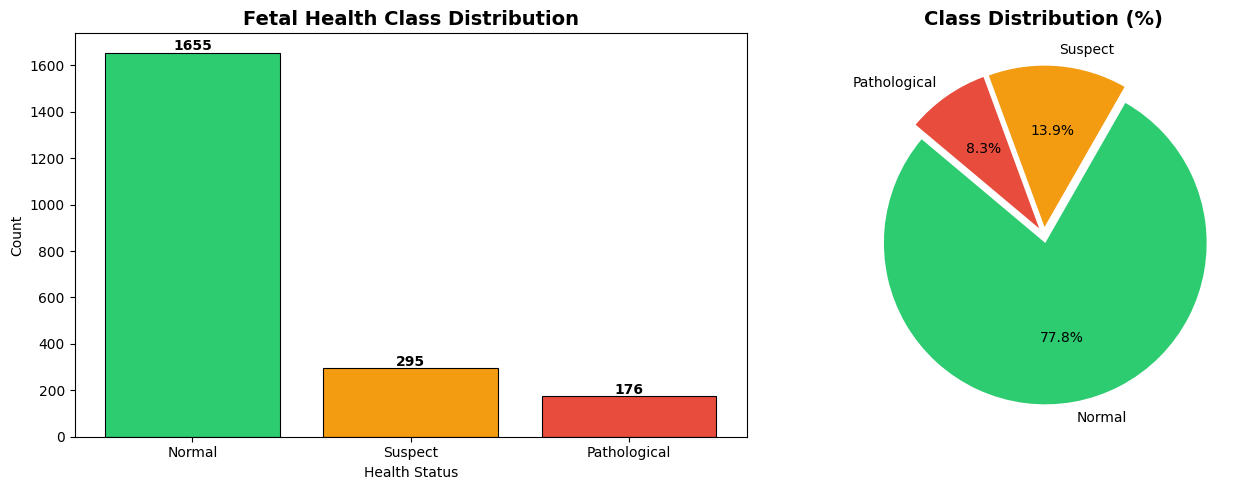

✅ Class Distribution plotted


In [5]:
label_map = {1.0: 'Normal', 2.0: 'Suspect', 3.0: 'Pathological'}
df['health_label'] = df['fetal_health'].map(label_map)

plt.figure(figsize=(14, 5))

# Count Plot
plt.subplot(1, 2, 1)
colors = ['#2ecc71', '#f39c12', '#e74c3c']
counts = df['health_label'].value_counts()
plt.bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.8)
plt.title('Fetal Health Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Health Status')
plt.ylabel('Count')
for i, v in enumerate(counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie Chart
plt.subplot(1, 2, 2)
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
        colors=colors, startangle=140, explode=(0.05, 0.05, 0.05))
plt.title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Class Distribution plotted")

In [6]:
print("Statistical Summary:")
df.describe().T.style.background_gradient(cmap='Blues')

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
baseline value,2126.000000,133.303857,9.840844,106.000000,126.000000,133.000000,140.000000,160.000000
accelerations,2126.000000,0.003178,0.003866,0.000000,0.000000,0.002000,0.006000,0.019000
fetal_movement,2126.000000,0.009481,0.046666,0.000000,0.000000,0.000000,0.003000,0.481000
uterine_contractions,2126.000000,0.004366,0.002946,0.000000,0.002000,0.004000,0.007000,0.015000
light_decelerations,2126.000000,0.001889,0.002960,0.000000,0.000000,0.000000,0.003000,0.015000
severe_decelerations,2126.000000,0.000003,0.000057,0.000000,0.000000,0.000000,0.000000,0.001000
prolongued_decelerations,2126.000000,0.000159,0.000590,0.000000,0.000000,0.000000,0.000000,0.005000
abnormal_short_term_variability,2126.000000,46.990122,17.192814,12.000000,32.000000,49.000000,61.000000,87.000000
mean_value_of_short_term_variability,2126.000000,1.332785,0.883241,0.200000,0.700000,1.200000,1.700000,7.000000
percentage_of_time_with_abnormal_long_term_variability,2126.000000,9.846660,18.396880,0.000000,0.000000,0.000000,11.000000,91.000000


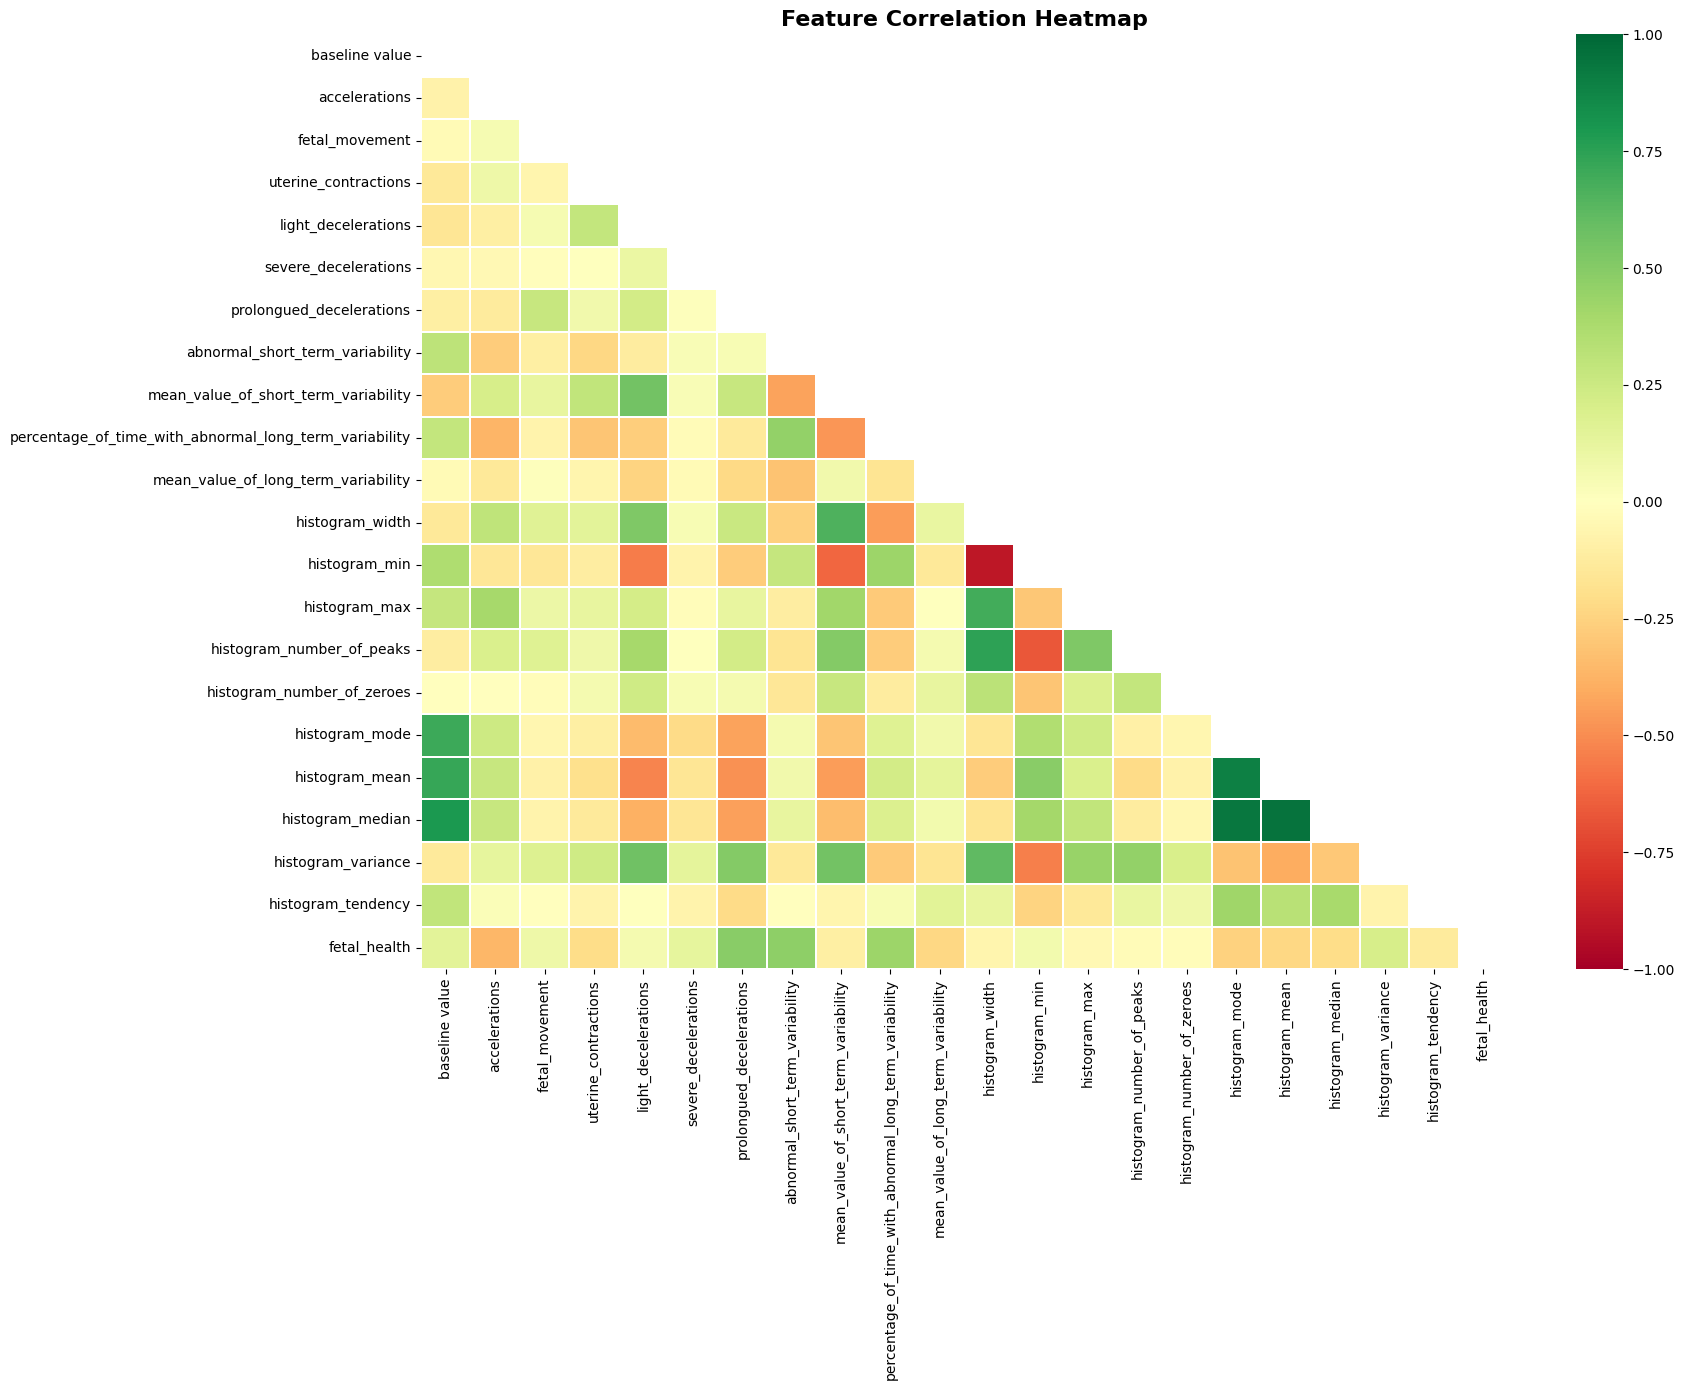

In [7]:
plt.figure(figsize=(18, 14))
corr = df.drop(['health_label'], axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdYlGn',
            linewidths=0.3, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

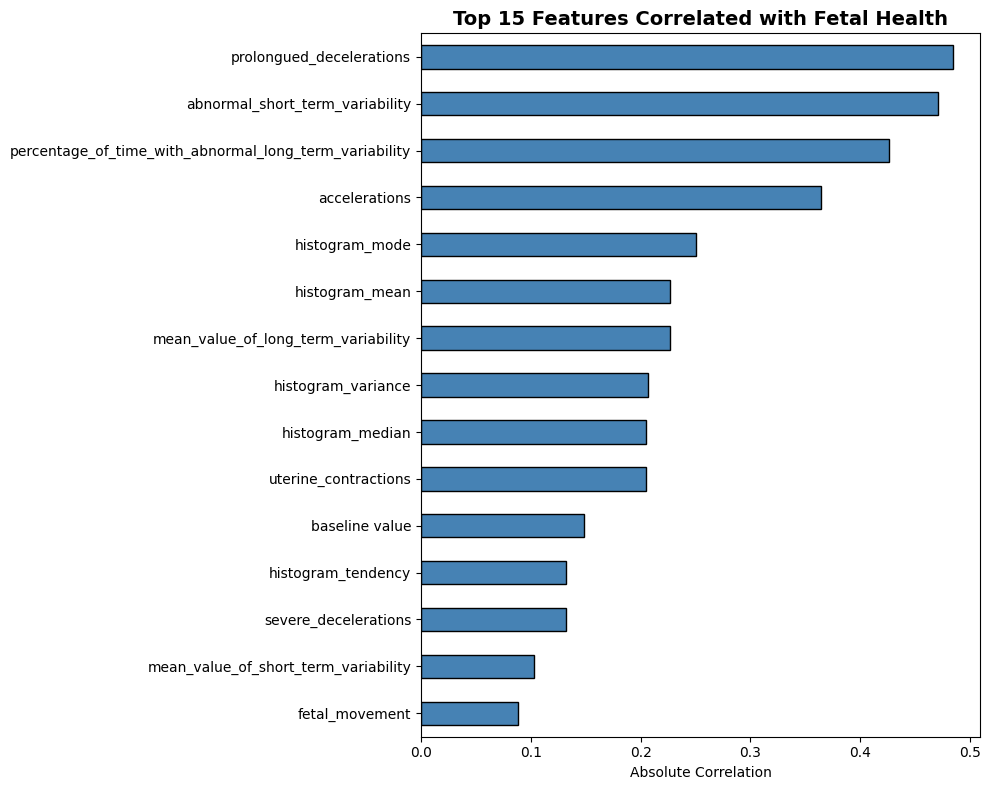

Top 5 most correlated features:
prolongued_decelerations                                  0.484859
abnormal_short_term_variability                           0.471191
percentage_of_time_with_abnormal_long_term_variability    0.426146
accelerations                                             0.364066
histogram_mode                                            0.250412
Name: fetal_health, dtype: float64


In [8]:
corr_target = df.drop(['health_label'], axis=1).corr()['fetal_health'].abs().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
corr_target[1:16].plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 15 Features Correlated with Fetal Health', fontsize=14, fontweight='bold')
plt.xlabel('Absolute Correlation')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_features_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 most correlated features:")
print(corr_target[1:6])

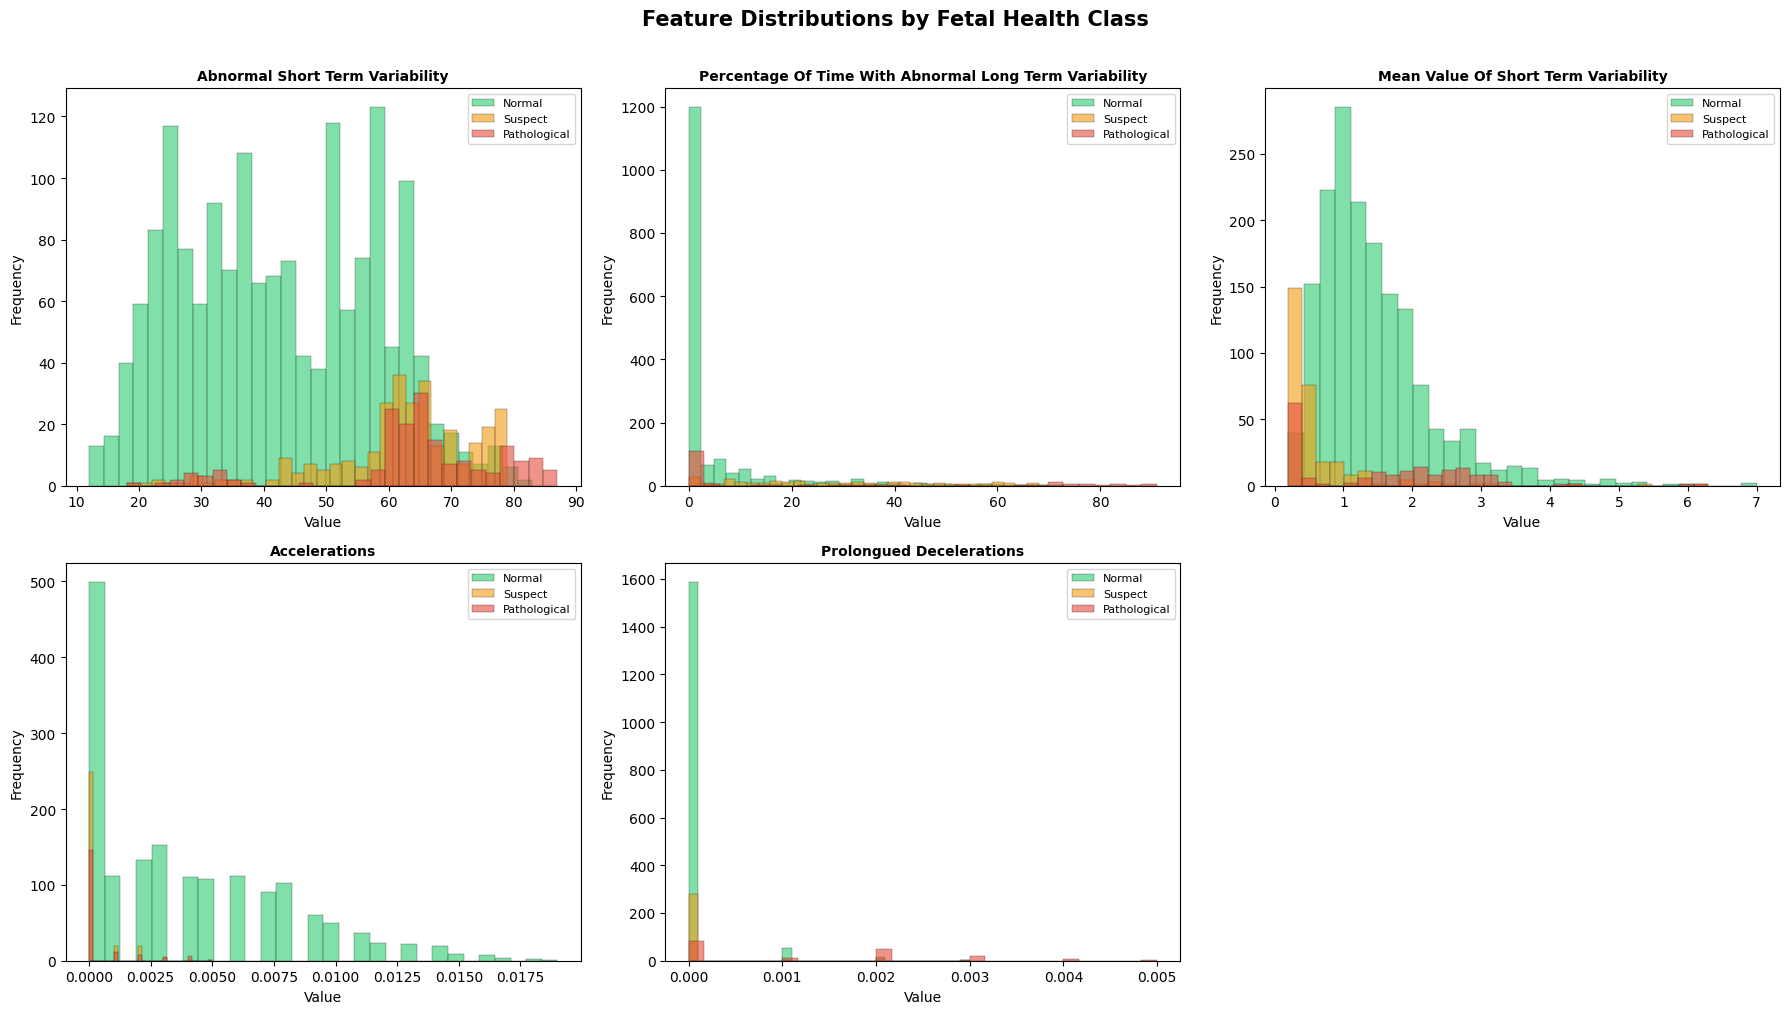

In [9]:
top_features = ['abnormal_short_term_variability', 'percentage_of_time_with_abnormal_long_term_variability',
                'mean_value_of_short_term_variability', 'accelerations', 'prolongued_decelerations']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    for label, color in zip(['Normal', 'Suspect', 'Pathological'], ['#2ecc71', '#f39c12', '#e74c3c']):
        subset = df[df['health_label'] == label][feat]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='black', linewidth=0.3)
    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

axes[-1].axis('off')
plt.suptitle('Feature Distributions by Fetal Health Class', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

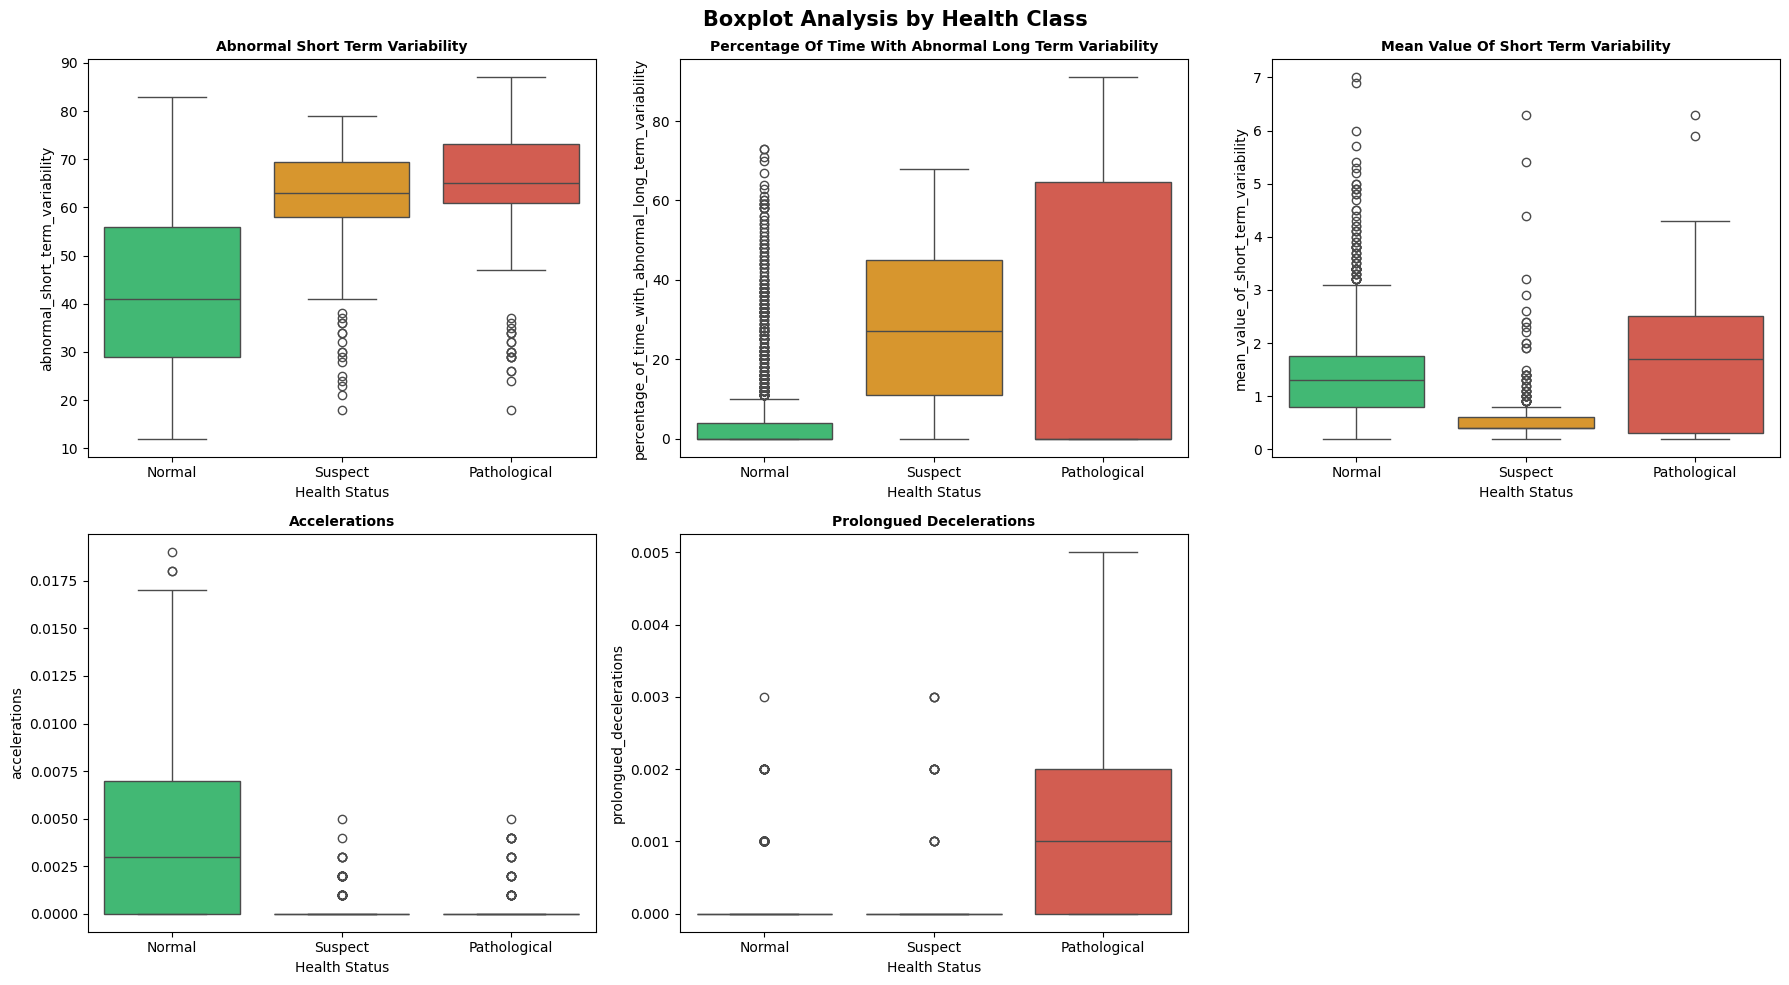

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

palette = {'Normal': '#2ecc71', 'Suspect': '#f39c12', 'Pathological': '#e74c3c'}

for i, feat in enumerate(top_features):
    sns.boxplot(x='health_label', y=feat, data=df, palette=palette, ax=axes[i], order=['Normal','Suspect','Pathological'])
    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Health Status')

axes[-1].axis('off')
plt.suptitle('Boxplot Analysis by Health Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Drop label column, keep numeric features
X = df.drop(['fetal_health', 'health_label'], axis=1)
y = df['fetal_health'].astype(int) - 1  # Convert to 0, 1, 2

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"Classes        : {np.unique(y)} → 0=Normal, 1=Suspect, 2=Pathological")

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nTrain size : {X_train.shape[0]}")
print(f"Test size  : {X_test.shape[0]}")
print("✅ Preprocessing complete!")

Features shape : (2126, 21)
Target shape   : (2126,)
Classes        : [0 1 2] → 0=Normal, 1=Suspect, 2=Pathological

Train size : 1700
Test size  : 426
✅ Preprocessing complete!


In [12]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=100, random_state=42,
                                          eval_metric='mlogloss', verbosity=0),
    'LightGBM'            : LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    'SVM'                 : SVC(kernel='rbf', probability=True, random_state=42)
}

results = {}
print("Training models...\n")
print(f"{'Model':<25} {'Accuracy':>10} {'AUC Score':>12}")
print("="*50)

for name, model in models.items():
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    results[name] = {'model': model, 'accuracy': acc, 'auc': auc,
                     'y_pred': y_pred, 'y_prob': y_prob}
    print(f"{name:<25} {acc*100:>9.2f}%  {auc:>12.4f}")

print("\n✅ All models trained!")

Training models...

Model                       Accuracy    AUC Score
Logistic Regression           88.50%        0.9614
Random Forest                 92.49%        0.9787
Gradient Boosting             92.96%        0.9617
XGBoost                       93.90%        0.9812
LightGBM                      94.37%        0.9811
SVM                           89.44%        0.9654

✅ All models trained!


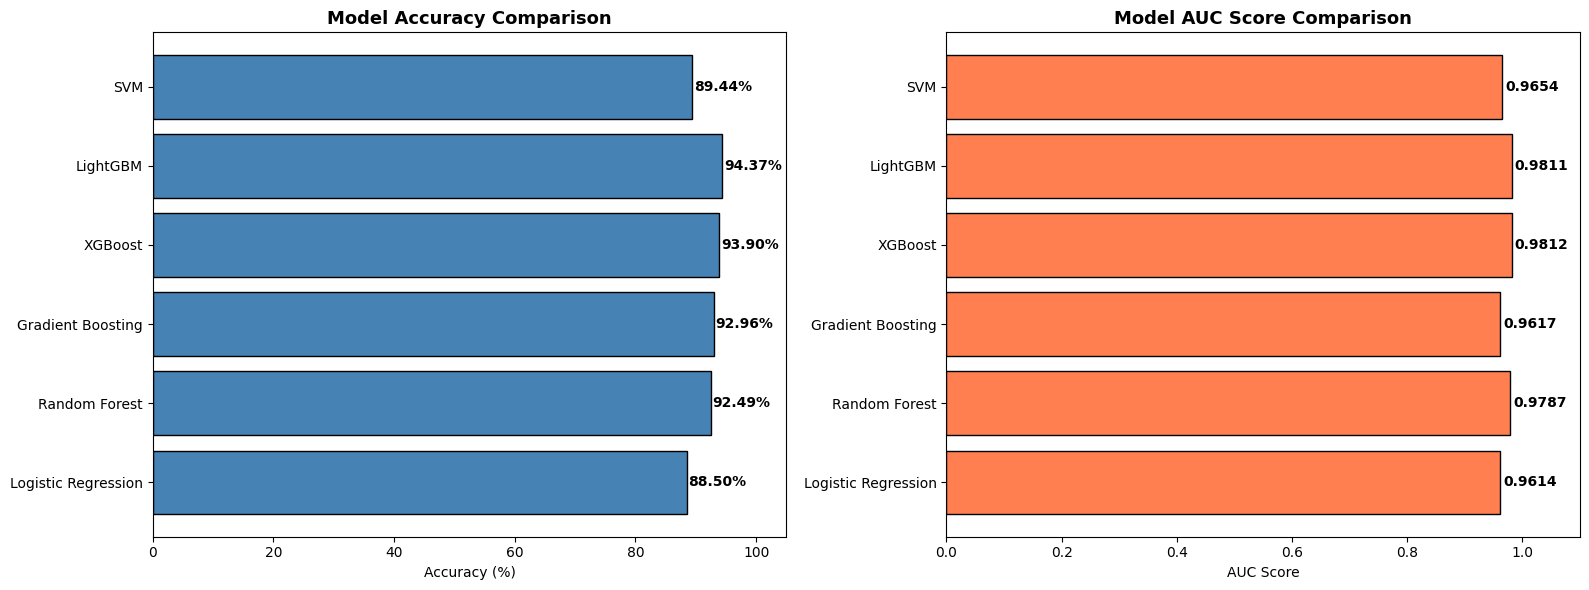

In [13]:
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] * 100 for m in model_names]
aucs        = [results[m]['auc'] for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy bar
bars = axes[0].barh(model_names, accuracies, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Accuracy (%)')
axes[0].set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, 105)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{acc:.2f}%', va='center', fontweight='bold')

# AUC bar
bars2 = axes[1].barh(model_names, aucs, color='coral', edgecolor='black')
axes[1].set_xlabel('AUC Score')
axes[1].set_title('Model AUC Score Comparison', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, 1.1)
for bar, auc in zip(bars2, aucs):
    axes[1].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{auc:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

🏆 Best Model: LightGBM
   Accuracy : 94.37%
   AUC Score: 0.9811


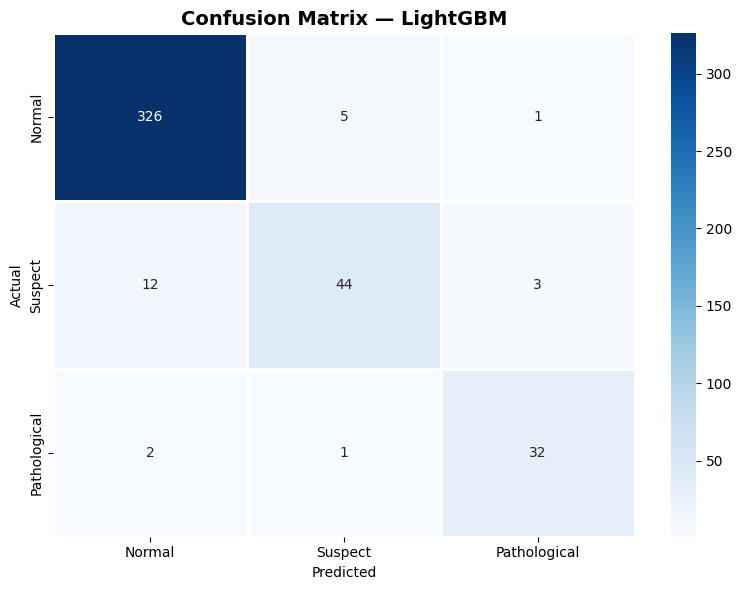


Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97       332
     Suspect       0.88      0.75      0.81        59
Pathological       0.89      0.91      0.90        35

    accuracy                           0.94       426
   macro avg       0.91      0.88      0.89       426
weighted avg       0.94      0.94      0.94       426



In [14]:
best_name = max(results, key=lambda x: results[x]['accuracy'])
best      = results[best_name]
print(f"🏆 Best Model: {best_name}")
print(f"   Accuracy : {best['accuracy']*100:.2f}%")
print(f"   AUC Score: {best['auc']:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, best['y_pred'])
labels = ['Normal', 'Suspect', 'Pathological']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, linewidths=1)
plt.title(f'Confusion Matrix — {best_name}', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, best['y_pred'], target_names=labels))

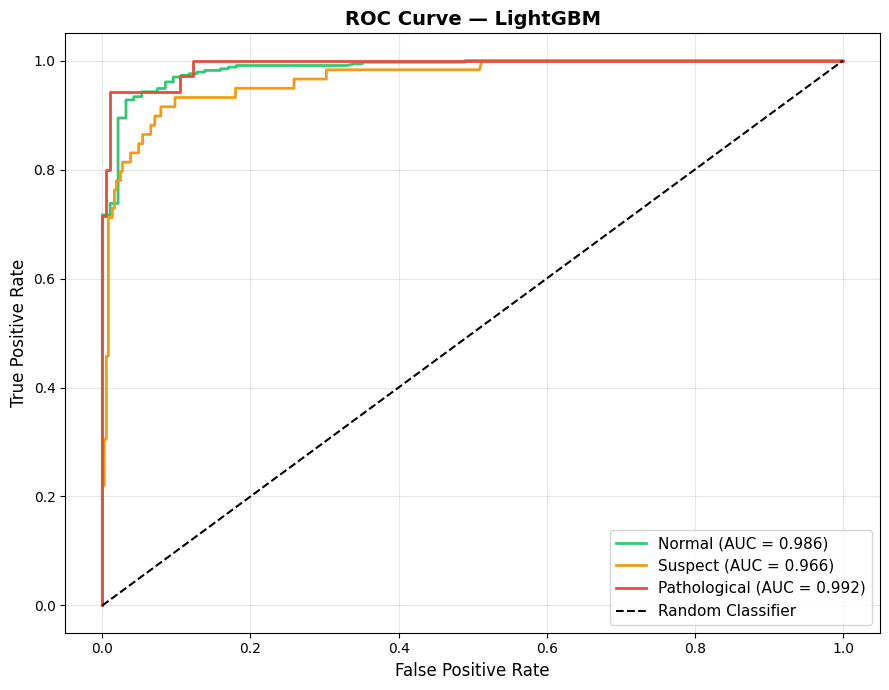

In [15]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
colors_roc  = ['#2ecc71', '#f39c12', '#e74c3c']

plt.figure(figsize=(9, 7))
for i, (label, color) in enumerate(zip(labels, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], best['y_prob'][:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], best['y_prob'][:, i])
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC = {auc_i:.3f})')

plt.plot([0,1],[0,1],'k--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve — {best_name}', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

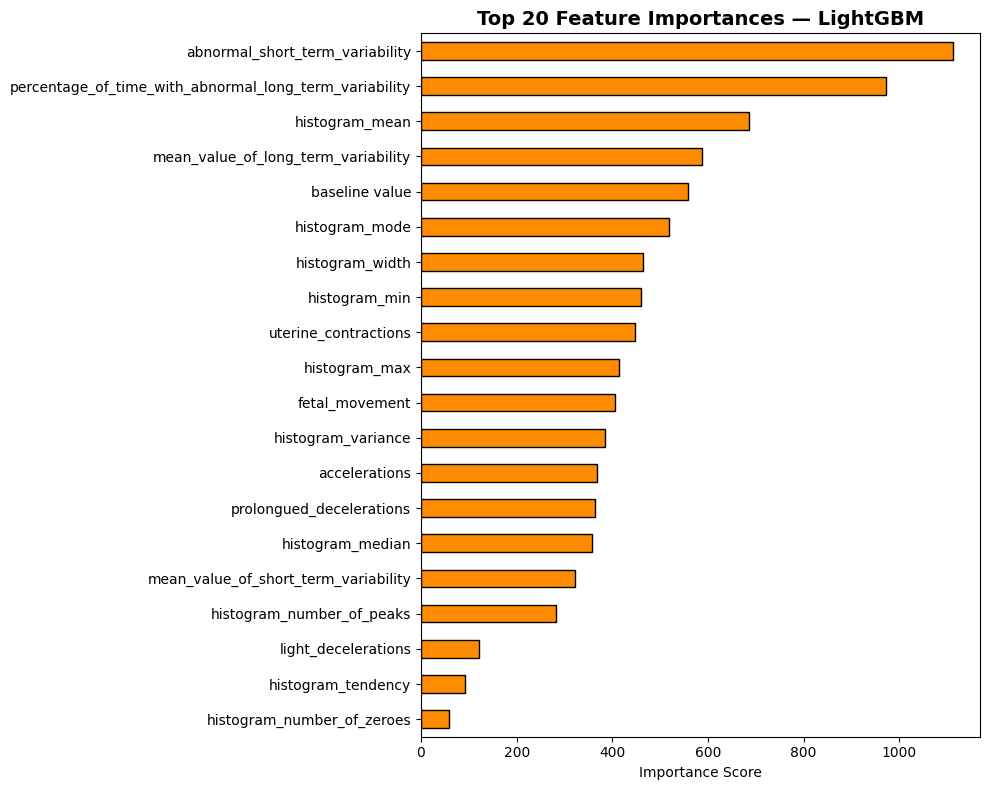

In [16]:
if hasattr(best['model'], 'feature_importances_'):
    importances = pd.Series(best['model'].feature_importances_, index=X.columns)
    top20 = importances.sort_values(ascending=False)[:20]

    plt.figure(figsize=(10, 8))
    top20.plot(kind='barh', color='darkorange', edgecolor='black')
    plt.title(f'Top 20 Feature Importances — {best_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"Feature importance not available for {best_name}")

In [17]:
print("Tuning XGBoost hyperparameters...")

param_grid = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [4, 6],
    'learning_rate' : [0.05, 0.1],
    'subsample'     : [0.8, 1.0]
}

xgb_base = XGBClassifier(random_state=42, eval_metric='mlogloss', verbosity=0)
grid_search = GridSearchCV(xgb_base, param_grid, cv=5,
                           scoring='accuracy', n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)

best_xgb   = grid_search.best_estimator_
xgb_pred   = best_xgb.predict(X_test)
xgb_prob   = best_xgb.predict_proba(X_test)
xgb_acc    = accuracy_score(y_test, xgb_pred)
xgb_auc    = roc_auc_score(y_test, xgb_prob, multi_class='ovr', average='macro')

print(f"\nBest Params   : {grid_search.best_params_}")
print(f"Tuned Accuracy: {xgb_acc*100:.2f}%")
print(f"Tuned AUC     : {xgb_auc:.4f}")

Tuning XGBoost hyperparameters...

Best Params   : {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Tuned Accuracy: 94.13%
Tuned AUC     : 0.9818


In [18]:
print("Running 5-Fold Cross Validation on best models...\n")

cv_models = {
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost Tuned' : best_xgb,
    'LightGBM'      : LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
}

print(f"{'Model':<20} {'Mean Acc':>10} {'Std Dev':>10}")
print("="*42)
for name, model in cv_models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy', n_jobs=-1)
    print(f"{name:<20} {scores.mean()*100:>9.2f}%  {scores.std()*100:>9.2f}%")

Running 5-Fold Cross Validation on best models...

Model                  Mean Acc    Std Dev
Random Forest            86.41%       5.96%
XGBoost Tuned            86.31%      11.62%
LightGBM                 86.36%      10.72%


In [19]:
# Determine final best model (XGBoost tuned vs original best)
final_model  = best_xgb if xgb_acc >= best['accuracy'] else best['model']
final_name   = 'XGBoost (Tuned)' if xgb_acc >= best['accuracy'] else best_name
final_acc    = max(xgb_acc, best['accuracy'])

# Save model and scaler
joblib.dump(final_model, '/content/drive/MyDrive/body_model.pkl')
joblib.dump(scaler,      '/content/drive/MyDrive/body_scaler.pkl')

print(f"✅ Final Model Saved : body_model.pkl")
print(f"✅ Scaler Saved      : body_scaler.pkl")
print(f"   Model Name        : {final_name}")
print(f"   Final Accuracy    : {final_acc*100:.2f}%")

✅ Final Model Saved : body_model.pkl
✅ Scaler Saved      : body_scaler.pkl
   Model Name        : LightGBM
   Final Accuracy    : 94.37%


In [20]:
def predict_fetal_health(feature_dict):
    """
    Predict fetal health from CTG features.
    Input : dict with all 21 CTG feature values
    Output: dict with prediction label + confidence scores
    """
    feature_names = list(X.columns)
    input_array   = np.array([[feature_dict[f] for f in feature_names]])

    # Scale only if model needs it (LR/SVM)
    model_needs_scaling = final_name in ['Logistic Regression', 'SVM']
    if model_needs_scaling:
        input_array = scaler.transform(input_array)

    pred   = final_model.predict(input_array)[0]
    prob   = final_model.predict_proba(input_array)[0]

    label_map = {0: 'Normal', 1: 'Suspect', 2: 'Pathological'}
    return {
        'prediction'    : label_map[pred],
        'confidence'    : round(float(np.max(prob)) * 100, 2),
        'probabilities' : {
            'Normal'       : round(float(prob[0]) * 100, 2),
            'Suspect'      : round(float(prob[1]) * 100, 2),
            'Pathological' : round(float(prob[2]) * 100, 2)
        }
    }

# ---- Test with one sample ----
sample = dict(zip(X.columns, X_test.iloc[0].values))
result = predict_fetal_health(sample)

print("="*40)
print("INFERENCE TEST")
print("="*40)
print(f"Prediction    : {result['prediction']}")
print(f"Confidence    : {result['confidence']}%")
print(f"Probabilities : {result['probabilities']}")
print(f"\nActual Label  : {['Normal','Suspect','Pathological'][y_test.iloc[0]]}")

INFERENCE TEST
Prediction    : Normal
Confidence    : 100.0%
Probabilities : {'Normal': 100.0, 'Suspect': 0.0, 'Pathological': 0.0}

Actual Label  : Normal


In [21]:
print("="*55)
print("        MODULE 2 — BODY ANALYSIS SUMMARY")
print("="*55)
print(f"  Dataset         : Fetal Health CTG (2126 records)")
print(f"  Features Used   : {X.shape[1]}")
print(f"  Classes         : Normal | Suspect | Pathological")
print(f"  Train Samples   : {X_train.shape[0]}")
print(f"  Test Samples    : {X_test.shape[0]}")
print(f"  Best Model      : {final_name}")
print(f"  Final Accuracy  : {final_acc*100:.2f}%")
print(f"  AUC Score       : {xgb_auc:.4f}")
print(f"  Model Saved     : body_model.pkl")
print(f"  Scaler Saved    : body_scaler.pkl")
print("="*55)
print("✅ Module 2 Complete!")

        MODULE 2 — BODY ANALYSIS SUMMARY
  Dataset         : Fetal Health CTG (2126 records)
  Features Used   : 21
  Classes         : Normal | Suspect | Pathological
  Train Samples   : 1700
  Test Samples    : 426
  Best Model      : LightGBM
  Final Accuracy  : 94.37%
  AUC Score       : 0.9818
  Model Saved     : body_model.pkl
  Scaler Saved    : body_scaler.pkl
✅ Module 2 Complete!
